# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

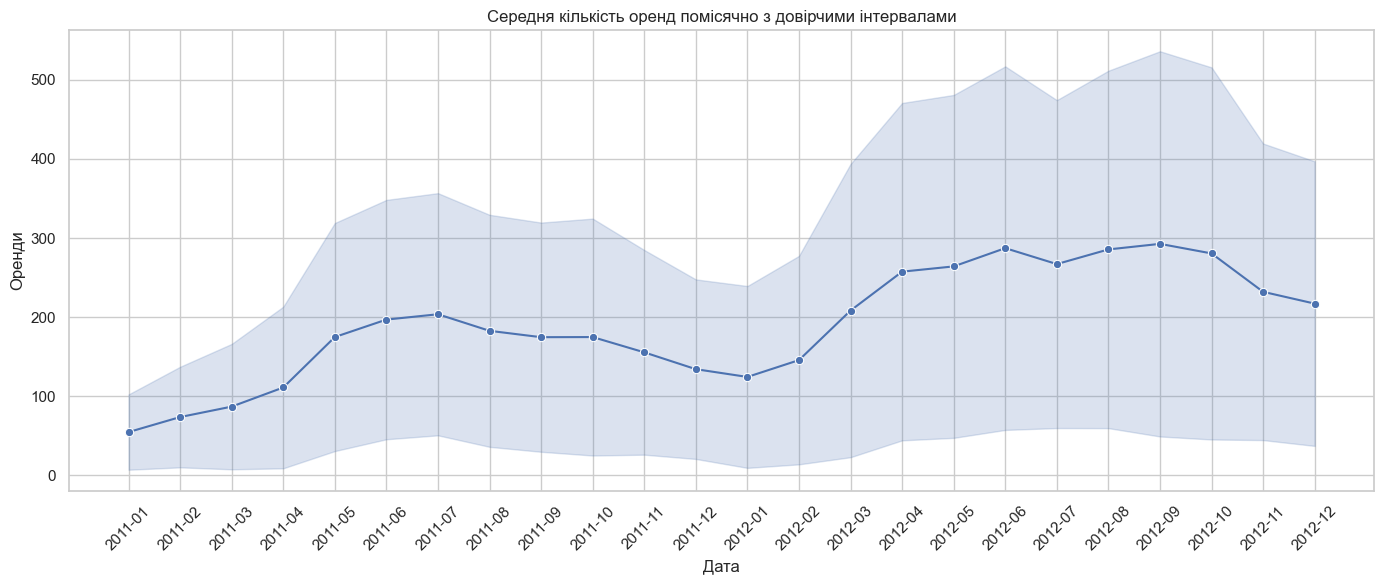

In [5]:
plt.figure(figsize=(14, 6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Середня кількість оренд помісячно з довірчими інтервалами')
plt.xlabel('Дата')
plt.ylabel('Оренди')
plt.xticks(rotation=45)
plt.tight_layout();

In [6]:
sd_month_year = df.groupby('month_year')['count'].std().sort_values(ascending=False)
sd_month_year.head(24)

month_year
2012-09    243.510415
2012-10    235.212983
2012-06    229.811672
2012-08    225.929425
2012-05    216.759524
2012-04    213.266556
2012-07    207.291102
2012-11    187.447854
2012-03    185.387528
2012-12    179.883538
2011-07    153.082654
2011-06    151.296297
2011-10    149.749304
2011-08    146.661600
2011-09    144.877431
2011-05    144.160643
2012-02    131.784817
2011-11    129.374278
2012-01    114.946616
2011-12    113.485627
2011-04    102.163250
2011-03     79.278388
2011-02     63.572141
2011-01     47.606250
Name: count, dtype: float64

В які місяці найбільша невизначеність в даних? - З березня по грудень 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

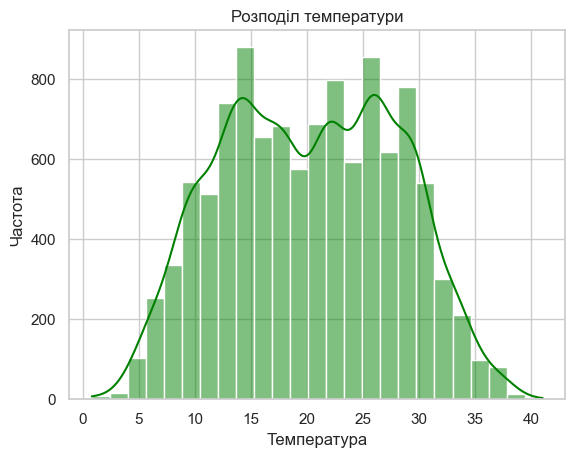

In [7]:
sns.histplot(data=df, x='temp', bins=25, kde=True, color='green')

plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.show()

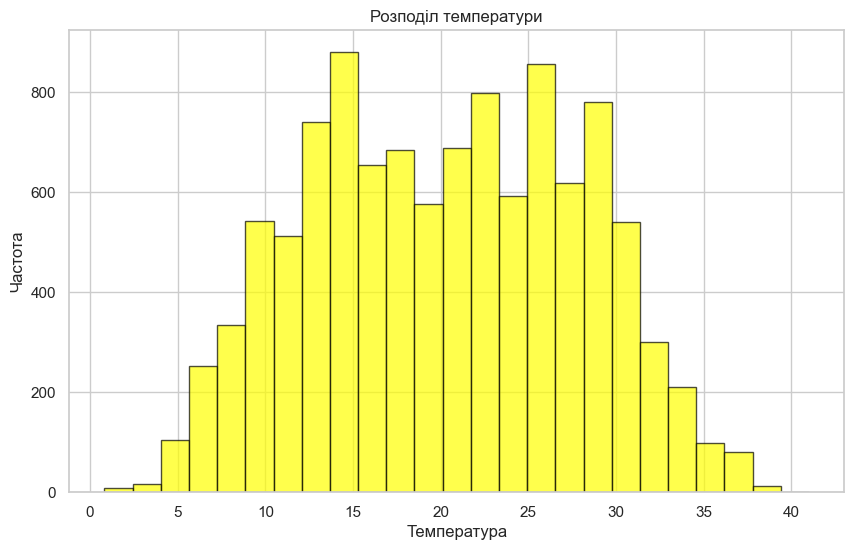

In [8]:
df['temp'].plot.hist(
    bins=25,
    figsize=(10, 6),
    alpha=0.7,
    color='yellow',
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура',
    ylabel='Частота'
);

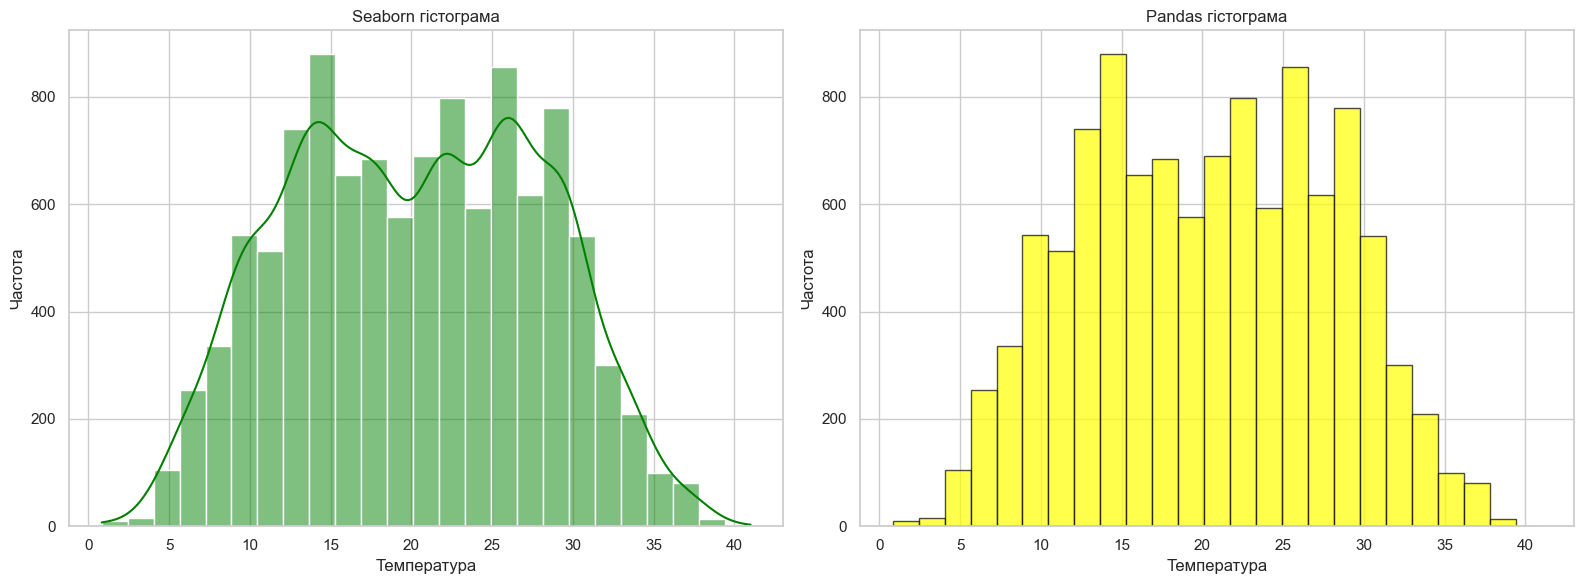

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x='temp',
    bins=25,
    kde=True,
    color='green',
    ax=axes[0]
)
axes[0].set_title('Seaborn гістограма')
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

df['temp'].plot.hist(
    bins=25,
    alpha=0.7,
    color='yellow',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Pandas гістограма')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

1. Яка візуальна різниця між Pandas та Seaborn гістограмами? У Seaborn є додаткова лінія.
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами? Ця лінія з'явилася, бо я додала параметр kde=True. KDE означає Kernel Density Estimate (оціночна щільність ядра). Це гладкий варіант гістограми, який допомагає побачити форму розподілу.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

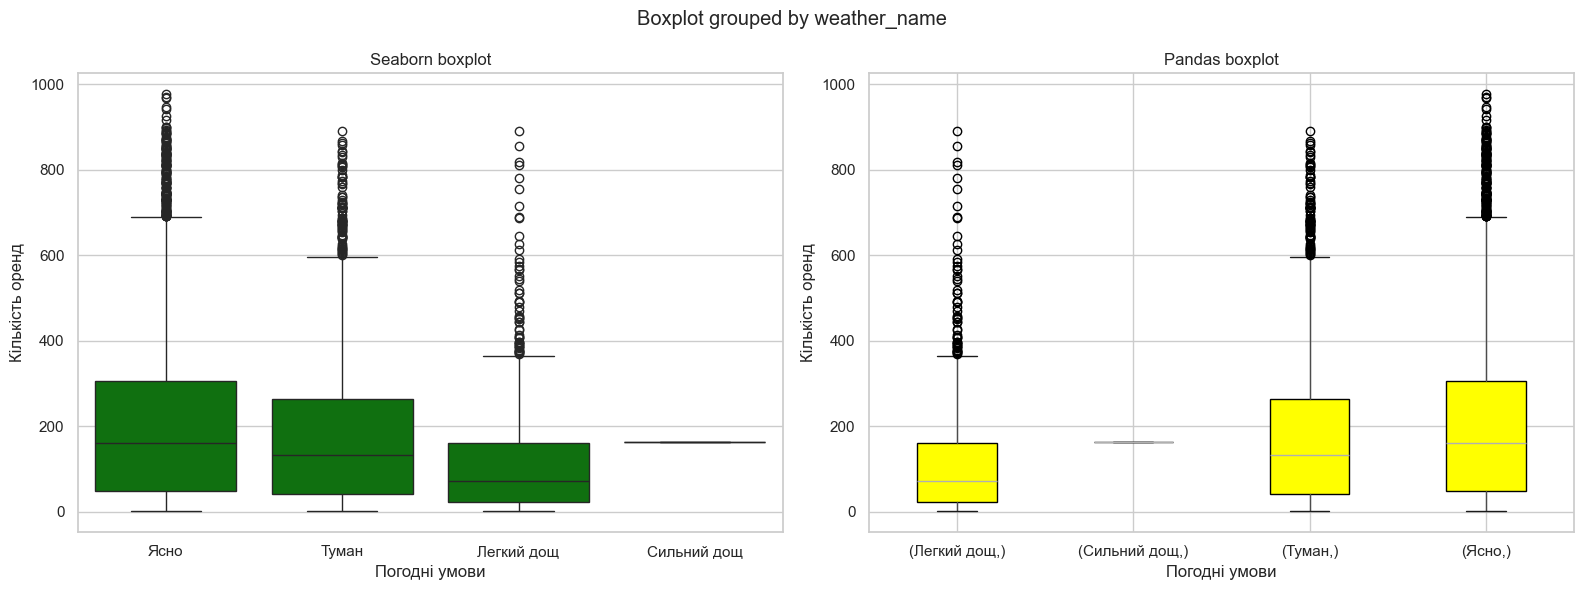

In [10]:
weather_labels = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

df['weather_name'] = df['weather'].map(weather_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df,
    x='weather_name',
    y='count',
    color='green',
    ax=axes[0]
)
axes[0].set_title('Seaborn boxplot')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')

df.boxplot(
    column='count',
    by=['weather_name'],
    patch_artist=True,
    boxprops=dict(facecolor='yellow', color='black'),
    ax=axes[1]
)
axes[1].set_title('Pandas boxplot')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

Яка візуальна різниця між Pandas та Seaborn бокс-плотами? Форма і розмір боксів відрізняються. Підписи погоди гарно відображаються в Seaborn boxplot, а в Pandas boxplot вони чомусь з дужками і крапкою. У Seaborn boxplot погодні умови у порядку спадання. Це візуально гарніше, ніж у Pandas boxplot, де погодні умови не відсортовані ні за порядком зростання, ні за порядком спадання.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [11]:
correlation = df[['count', 'temp', 'atemp', 'humidity', 'windspeed']].corr()
correlation

,count,temp,atemp,humidity,windspeed
count,1.000000,0.394454,0.389784,-0.317371,0.101369
temp,0.394454,1.000000,0.984948,-0.064949,-0.017852
atemp,0.389784,0.984948,1.000000,-0.043536,-0.057473
humidity,-0.317371,-0.064949,-0.043536,1.000000,-0.318607
windspeed,0.101369,-0.017852,-0.057473,-0.318607,1.000000


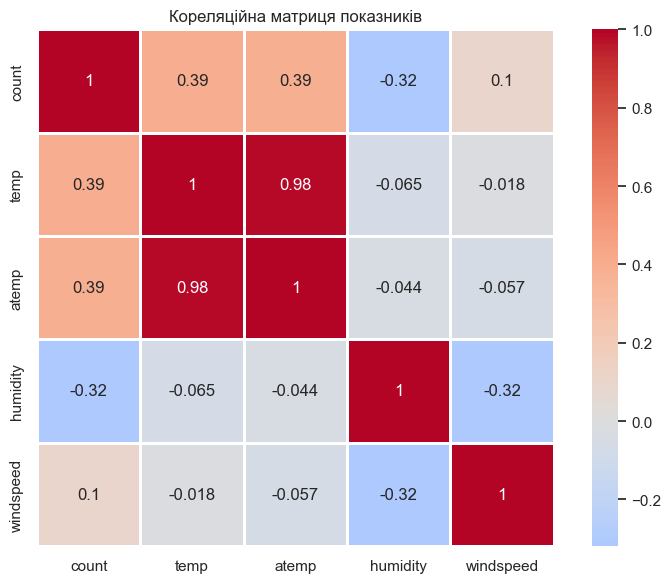

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)? Найсильніший позитивний зв'язок count має з temp і atemp, а найсильніший негативний - з humidity.
2. Яка кореляція між temp та atemp? Чому? Між temp і atemp сильна позитивна кореляція, тому що вони мають дуже близькі показники.
3. Які змінні мають негативну кореляцію? Найсильніша негативна кореляція спостерігається між count і humidity та між humidity і windspeed.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


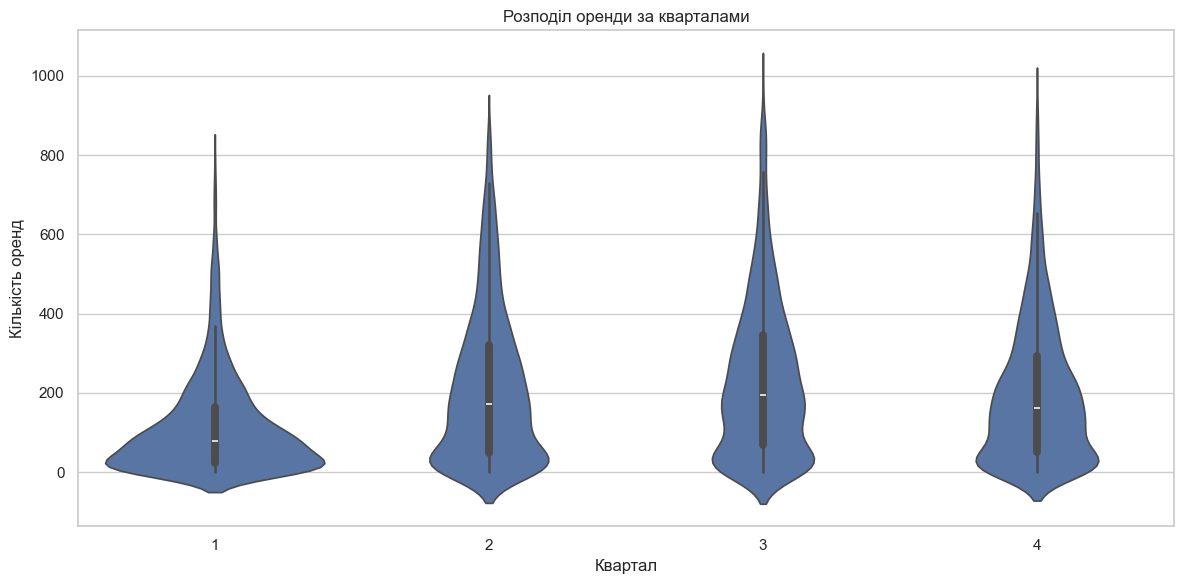

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count')
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

1. Що показує "товщина" violin plot? Вона показує щільність даних. Де скрипка ширша, там зосереджено більше значень.
2. В якому кварталі найбільша варіабельність оренди? У третьому.
3. Яка перевага violin plot над звичайним box plot? Violin plot поєднує в собі інформативність boxplot і наочність гістограми, показуючи не лише медіану та квартилі, а й повну форму розподілу. Він дозволяє чітко побачити, де дані зосереджені найбільше та чи має розподіл кілька піків. Завдяки цьому violin plot дає глибше розуміння структури даних і їхньої варіабельності.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

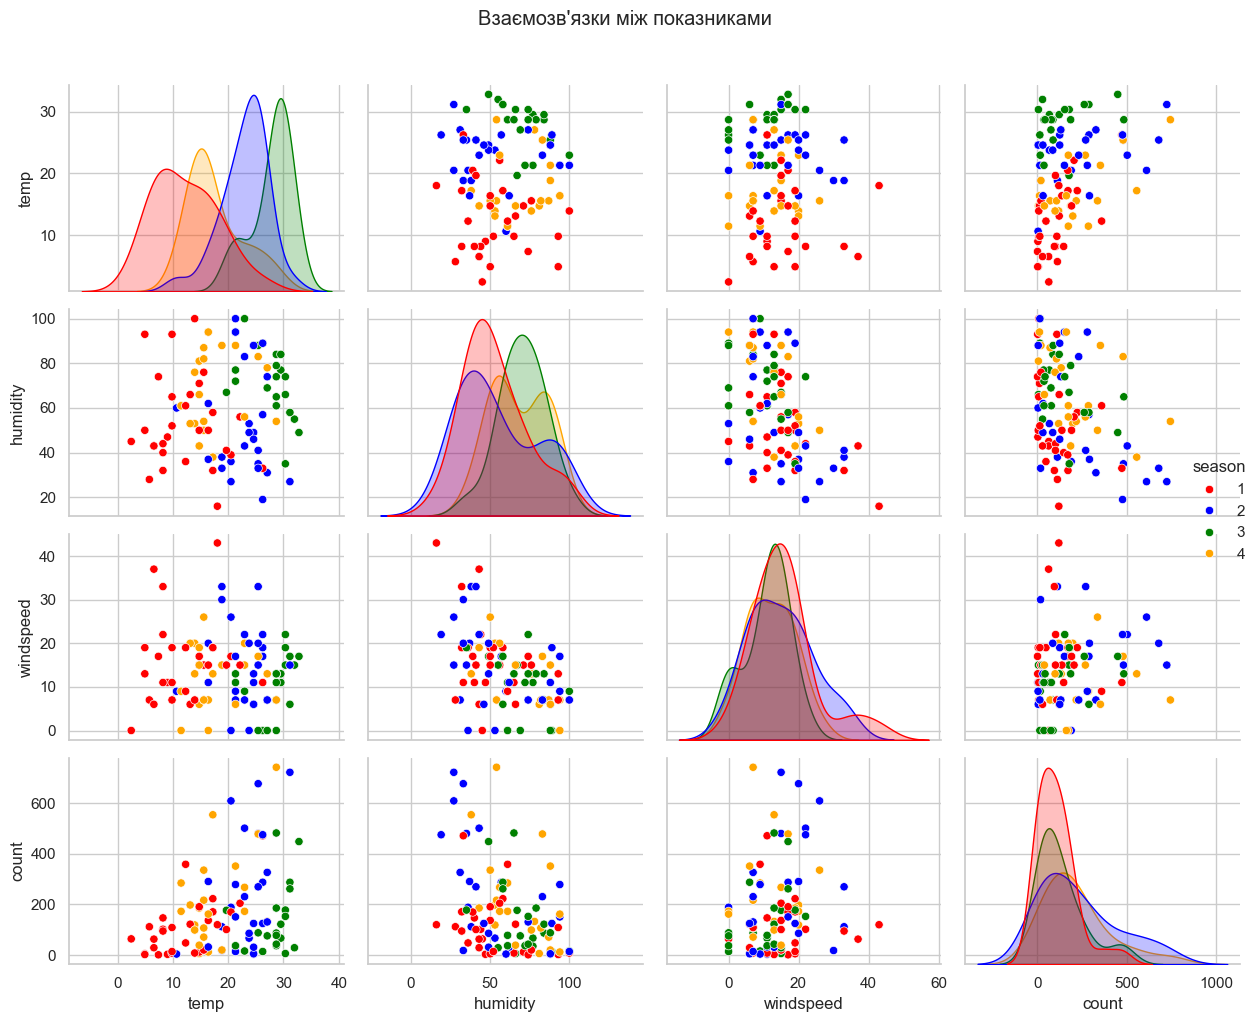

In [ ]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]
sample_df = sample_df.sample(100)
g = sns.pairplot(sample_df, hue="season", palette=["red", "blue", "green", "orange"], height=2.5, aspect=1.2)
g.figure.suptitle("Взаємозв'язки між показниками", y=1.02)
plt.tight_layout()
plt.show()

1. Між якими змінними спостерігається найсильніший лінійний зв'язок? Між temp і count.
2. Яка характеристика найбільше відрізняється між кварталами? Температура.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

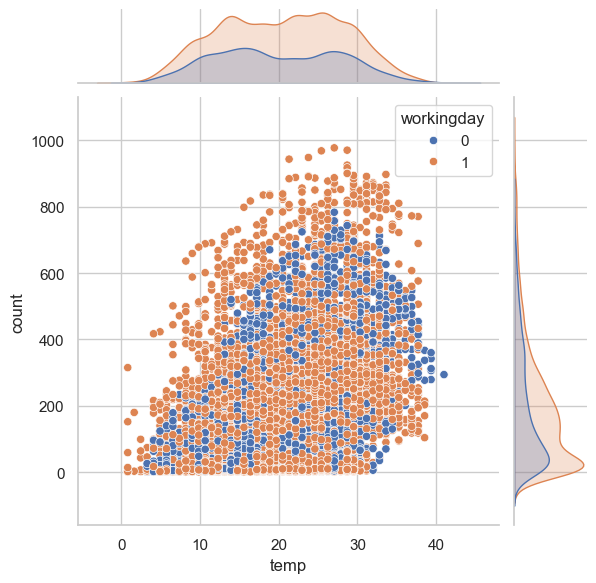

In [25]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday");

1. Що показують графіки по краях? Зверху - розподіл температури за неробочими/робочими днями. Збоку - розподіл оренди за неробочими/робочими днями.
2. Чи є різниця у поведінці користувачів у робочий і неробочий день? Так, у робочі дні користувачі більше орендують велосипеди.